In [1]:
import einsteinpy.symbolic as es
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
from scipy.integrate import solve_ivp
import spiceypy as spy

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [4]:
G, M, c, T, r, teta, fi = sp.symbols('G M c T r theta phi')



gmat = np.diag([1-2*G*M/(c**2*r), -1/(1-2*G*M/(c**2*r)), -r**2, -r**2*sp.sin(teta)**2])
coordenadas = T, r, teta, fi
gmet = es.MetricTensor(gmat, coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)
Gab.tensor()

[[[0, G*M/(r*(-2*G*M + c**2*r)), 0, 0], [G*M/(r*(-2*G*M + c**2*r)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[-G*M*(2*G*M - c**2*r)/(c**4*r**3), 0, 0, 0], [0, G*M*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2), 0, 0], [0, 0, (2*G*M - c**2*r)/c**2, 0], [0, 0, 0, (2*G*M - c**2*r)*sin(theta)**2/c**2]], [[0, 0, 0, 0], [0, 0, 1/r, 0], [0, 1/r, 0, 0], [0, 0, 0, -sin(theta)*cos(theta)]], [[0, 0, 0, 0], [0, 0, 0, 1/r], [0, 0, 0, cos(theta)/sin(theta)], [0, 1/r, cos(theta)/sin(theta), 0]]]

In [10]:
xpp = sp.symbols(r'\ddot{T} \ddot{r} \ddot{theta} \ddot{phi}')
xp = sp.symbols(r'\dot{T} \dot{r} \dot{theta} \dot{phi}')

for sigma in range(4):
    ecuacion = 0
    for mu in range(4):
        for nu in range(4):
            ecuacion += -Gab[sigma, mu, nu] * xp[mu] * xp[nu]

    ecuacion = sp.Eq(xpp[sigma],ecuacion)
    display(ecuacion)

Eq(\ddot{T}, -2*G*M*\dot{T}*\dot{r}/(r*(-2*G*M + c**2*r)))

Eq(\ddot{r}, G*M*\dot{T}**2*(2*G*M - c**2*r)/(c**4*r**3) - G*M*\dot{r}**2*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2) - \dot{phi}**2*(2*G*M - c**2*r)*sin(theta)**2/c**2 - \dot{theta}**2*(2*G*M - c**2*r)/c**2)

Eq(\ddot{theta}, \dot{phi}**2*sin(theta)*cos(theta) - 2*\dot{r}*\dot{theta}/r)

Eq(\ddot{phi}, -2*\dot{phi}*\dot{r}/r - 2*\dot{phi}*\dot{theta}*cos(theta)/sin(theta))

In [8]:
def edg_schwarzschild(tau, Ys, G, M, c):
    T, r, teta, fi, Ut, Ur, Uteta, Ufi = Ys
    rs= 2 * G * M / c**2

    # Derivadas de las coordenadas
    dT_dtau = Ut
    dr_dtau = Ur
    dteta_dtau = Uteta
    dfi_dtau = Ufi

    # Factor común
    denom = (c**2 * r - 2 * G * M) * r**2

    # Derivadas de las 4-velocidades (ecuaciones geodésicas de Schwarzschild)
    # d²T/dτ² = -Γ⁰₀ᵢ Uⁱ U⁰
    dUt_dtau = (2 * G * M / (c**2 * r**2 - 2 * G * M * r)) * (r * Ur) * Ut
    
    # d²r/dτ² = -Γʳ₀₀ U⁰² - Γʳⱼₖ Uʲ Uᵏ
    dUr_dtau = (G * M * (c**2 * r - 2 * G * M) / (c**4 * r**3)) * Ut**2 - (Ur**2 + Uteta**2 + Ufi**2) * (G * M / (c**2 * r**3))

    # d²θ/dτ² = -Γ^θ₀₀ U⁰² - Γ^θⱼₖ Uʲ Uᵏ
    dUteta_dtau = (G * M * (c**2 * r - 2 * G * M) / (c**4 * r**3)) * Ut**2 - (Ur**2 + Uteta**2 + Ufi**2) * (G * M * np.cos(teta) / (c**2 * r**3))

    # d²φ/dτ² = -Γ^φ₀₀ U⁰² - Γ^φⱼₖ Uʲ Uᵏ
    dUfi_dtau = (G * M * (c**2 * r - 2 * G * M) / (c**4 * r**3)) * Ut**2 - (Ur**2 + Uteta**2 + Ufi**2) * (G * M / (c**2 * r**3))

    return [dT_dtau, dr_dtau, dteta_dtau, dfi_dtau,
            dUt_dtau, dUr_dtau, dUteta_dtau, dUfi_dtau]

In [9]:
edg_schwarzschild(1, [1, 1, 1, 1, 1, 1, 1, 1], 2, 2, 2)

[1, 1, 1, 1, -2.0, -4.0, np.float64(-2.6209069176044193), -4.0]

In [11]:
# Unidades relativistas: c = 1, c = UL / UT
UM = pc.constantes.M_sun # en kg
UL = pc.constantes.G * UM / pc.constantes.c**2 # en metros
UT = UL / pc.constantes.c

# Unidades derivadas
UV = UL / UT
UA = UL / UT**2

# Constantes
G = 1
C = 1

UL, UT, UV, UA, C

(np.float64(1476.6250380501249),
 np.float64(4.9254909476412675e-06),
 np.float64(299792458.0),
 np.float64(60865497711160.234),
 1)

In [25]:
M = 1

t0 = 0
r0 = 500e3 / UL # 5000 km
teta0 = np.pi / 2
fi0 = 0 


vr0 = 0.05 
vteta0 = 0
vfi0 = np.sqrt(G * M / r0)/ r0 # velocidad tangencial circular

In [21]:
T0 = C*t0
# Las posiciones son las mismas
g00 = 1 - 2*G*M/ (C**2 * r0)
g11 = -1 / (1 - 2*G*M/ (C**2 * r0))
g22 = -r0**2    
g33 = -r0**2 * np.sin(teta0)**2

Ut0 = 1 / np.sqrt(g00 + g11*vr0**2 + g22*vteta0**2 + g33*vfi0**2)
Ur0 = vr0 * Ut0 / C
Uteta0 = vteta0 * Ut0 / C
Ufi0 = vfi0 * Ut0 / C

T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Ufi0

(0,
 np.float64(3386.0999720026907),
 1.5707963267948966,
 0,
 np.float64(1.0016980415063752),
 np.float64(0.050084902075318766),
 np.float64(0.0),
 np.float64(5.083784824552734e-06))

In [22]:
T = 2*np.pi * np.sqrt(r0**3 / (G*M))

taus = np.linspace(0, 0.98*T, 1000)
Ys0 = [T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Ufi0]
solucion = solve_ivp(edg_schwarzschild, (taus[0], taus[-1]), Ys0, t_eval=taus, args=(G, M, C), method='Radau')

In [23]:
ts = solucion.y[0] / C * UT
rs = solucion.y[1] * UL
tetas = solucion.y[2] 
phis = solucion.y[3] 

#convertir a oordenadas cartecianas para graficar
xs= rs*np.sin(tetas)*np.cos(phis)
ys= rs*np.sin(tetas)*np.sin(phis)
zs= rs*np.cos(tetas)

(np.float64(-1126718498063.7124),
 np.float64(149123136372.4614),
 np.float64(-87716259446.55824),
 np.float64(1841900532995.3613))

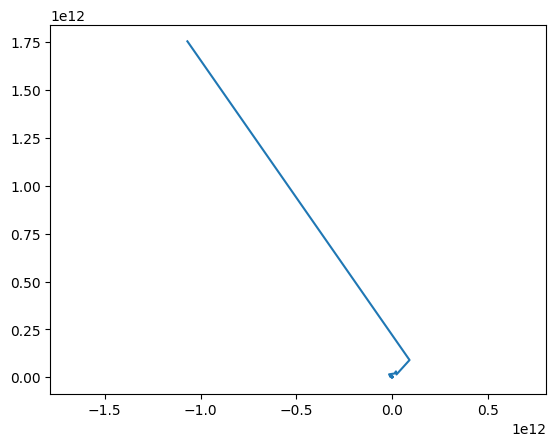

In [26]:
plt.plot(xs, ys)
plt.axis('equal')